# Hotel Booking Demand — A/B Testing & Analytics

**Датасет:** [Hotel booking demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand) (Kaggle)  
**Контекст:** Travel Tech — онлайн-платформа бронирования отелей  
**Цель:** Симуляция полного цикла A/B-эксперимента: от гипотезы до бизнес-решения

---

## Содержание
1. [Описание датасета и EDA](#1)
2. [Travel Tech метрики и KPI](#2)
3. [Когортный анализ](#3)
4. [Гипотеза и планирование эксперимента](#4)
5. [Разделение на группы — хэширование с солью](#5)
6. [A/A-тест](#6)
7. [A/B-тест: t-тест и Mann-Whitney](#7)
8. [Bootstrap](#8)
9. [CUPED](#9)
10. [Байесовский A/B-тест](#10)
11. [Guardrail-метрики](#11)
12. [ROI и бизнес-рекомендация](#12)

---
## О датасете

Датасет содержит 119 390 записей о бронированиях двух отелей — **City Hotel** и **Resort Hotel** — за период с июля 2015 по август 2017 года. Каждая строка соответствует одному бронированию, которое может быть выполнено или отменено.

**Что можно извлечь из этих данных:**

- **Паттерны спроса.** Поля `arrival_date_year`, `arrival_date_month` и `arrival_date_day_of_month` позволяют восстановить временные ряды бронирований и изучить сезонность.

- **Прокси-выручка.** Поле `adr` (Average Daily Rate) в сочетании с `stays_in_week_nights + stays_in_weekend_nights` даёт общую выручку на бронирование. Это прокси, но для относительных сравнений в A/B-тесте этого достаточно.

- **Поведение при отмене.** Бинарное поле `is_canceled` — прямая продуктовая метрика. Можно изучить, что именно влияет на отмены.

- **Сегменты клиентов.** Комбинация `market_segment` (Direct, Online TA, Offline TA/TO, Corporate, Groups и др.) и `distribution_channel` отражает реальную сегментацию трафика на платформе.

- **Сигналы лояльности.** Поле `is_repeated_guest` позволяет оценить retention.

- **Характеристики бронирования.** `lead_time`, `total_of_special_requests`, `required_car_parking_spaces` и несоответствие типа комнаты (`reserved_room_type != assigned_room_type`) — потенциальные сигналы намерений и удовлетворённости клиента.

**Ограничения:**

В датасете нет уникальных user ID. Каждая строка - это бронирование, а не сессия пользователя. Гость, забронировавший трижды, представлен тремя отдельными строками. Следовательно, наш A/B-сплит происходит на уровне бронирований. В реальном эксперименте разделение проводилось по user ID. В качестве суррогатного ID мы будем использовать индекс строки.

Данные исторические и наблюдательные. «Эксперимент» является ретроспективной симуляцией: мы берём исторические бронирования Online TA, случайным образом делим их на тест и контроль, затем искусственно добавляем эффект в тестовую группу.

## 0. Импорты и конфигурация

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind, norm, beta, chisquare
from statsmodels.stats.power import zt_ind_solve_power
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
import hashlib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

COLOR_CONTROL = '#4C72B0'
COLOR_TEST    = '#DD8452'

print('Libraries loaded.')

Libraries loaded.


<a id='1'></a>
---
## 1. Загрузка данных и EDA

In [2]:
df = pd.read_csv('hotel_bookings.csv')

print(f'Dataset shape: {df.shape}')
print(f'Years covered: {sorted(df["arrival_date_year"].unique())}')
df.head(3)

Dataset shape: (119390, 32)
Years covered: [np.int64(2015), np.int64(2016), np.int64(2017)]


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


In [3]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [4]:
# ADR = 0 или аномально высокие значения — ошибки данных или бесплатные размещения. Исключаем
df = df[(df['adr'] > 0) & (df['adr'] < 5000)].copy()

df['children'] = df['children'].fillna(0).astype(int)

month_map = {
    'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
    'July':7,'August':8,'September':9,'October':10,'November':11,'December':12
}
df['arrival_month_num'] = df['arrival_date_month'].map(month_map)
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_month_num'].astype(str) + '-' +
    df['arrival_date_day_of_month'].astype(str)
)

df['total_nights']  = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_revenue'] = df['adr'] * df['total_nights']

# Суррогатный user_id: каждое бронирование - один пользователь.
df['user_id'] = df.index.astype(str)

print(f'After cleaning: {df.shape[0]:,} bookings')
df[['adr','total_nights','total_revenue','arrival_date']].describe()

After cleaning: 117,429 bookings


,adr,total_nights,total_revenue,arrival_date
count,117429.000000,117429.000000,117429.000000,117429
mean,103.485715,3.457664,363.778635,2016-08-29 20:43:14.670822400
min,0.260000,1.000000,1.000000,2015-07-01 00:00:00
25%,70.530000,2.000000,151.000000,2016-03-16 00:00:00
50%,95.000000,3.000000,270.000000,2016-09-08 00:00:00
75%,126.000000,4.000000,450.000000,2017-03-20 00:00:00
max,510.000000,69.000000,7590.000000,2017-08-31 00:00:00
std,46.708039,2.534835,335.157327,NaN


ADR имеет правостороннее смещение: среднее (\~103.5) заметно выше медианы (\~95).

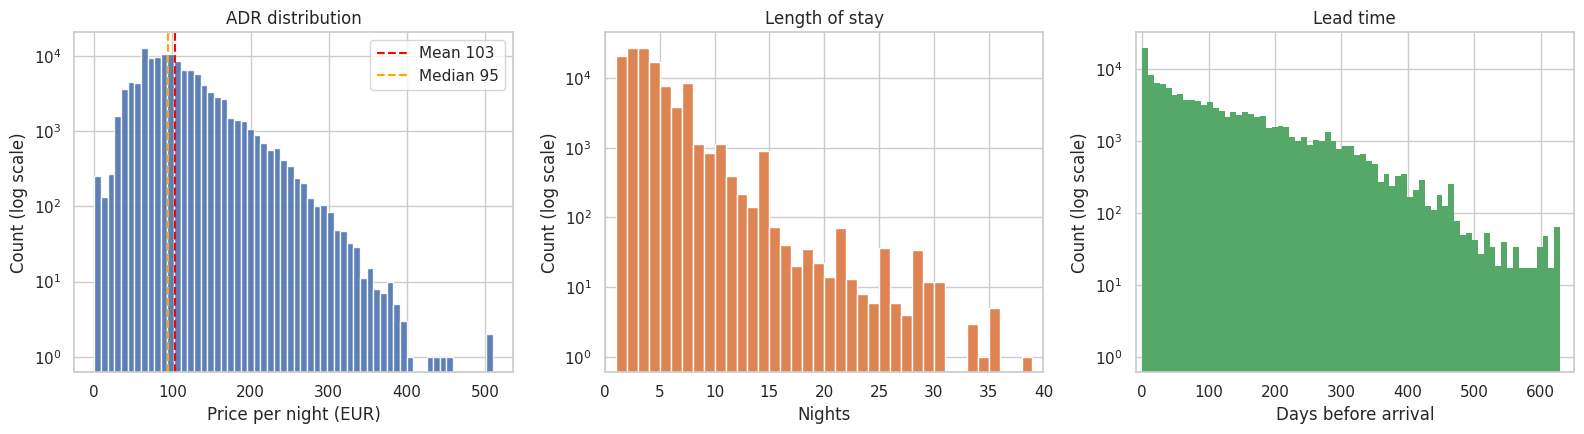

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. ADR distribution
axes[0].hist(df['adr'], bins=60, color=COLOR_CONTROL, edgecolor='white', alpha=0.9)
axes[0].axvline(df['adr'].mean(),   color='red',    ls='--', label=f'Mean {df["adr"].mean():.0f}')
axes[0].axvline(df['adr'].median(), color='orange', ls='--', label=f'Median {df["adr"].median():.0f}')
axes[0].set_title('ADR distribution')
axes[0].set_xlabel('Price per night (EUR)')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_yscale('log')
axes[0].legend()

# 2. Length of stay
max_nights = int(df['total_nights'].max())
axes[1].hist(df['total_nights'], bins=range(1, min(max_nights, 40)), color=COLOR_TEST, edgecolor='white')
axes[1].set_title('Length of stay')
axes[1].set_xlabel('Nights')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_yscale('log')
axes[1].set_xlim(0, 40)

# 3. Lead time
axes[2].hist(df['lead_time'], bins=80, color='#55A868', edgecolor='none')
axes[2].set_title('Lead time')
axes[2].set_xlabel('Days before arrival')
axes[2].set_ylabel('Count (log scale)')
axes[2].set_yscale('log')
axes[2].set_xlim(-10, 650)

plt.tight_layout()
plt.show()


<a id='2'></a>
---
## 2. Travel Tech метрики и KPI

Для платформы бронирования отелей иерархия метрик строится вокруг объема бронирований, их доживаемости до заселения и финансовой эффективности:

*   **North Star Metric**: **Total realised revenue** - суммарная реализованная выручка (рассчитывается только по выполненным бронированиям, где `is_canceled == 0`).
*   **Основная продуктовая метрика**: **Cancellation rate** - доля отмененных бронирований. Снижение отмен - ключевой рычаг роста реализованной выручки. Базовым объемом для этой и других долевых метрик выступает общее число заказов (**Total bookings**).
*   **Вторичные метрики**:
    *   **ADR mean/median** - средняя и медианная стоимость ночи, отражающая качество ценообразования.
    *   **Lead time mean** - насколько заранее пользователи бронируют - прокси доверия к платформе.
    *   **Length of stay mean** - средняя продолжительность проживания.
    *   **Repeat guest rate** - доля повторных клиентов.
*   **Guardrail-метрики**: **Avg revenue per booking** - средняя выручка на реализованное бронирование. При внедрении фич для снижения отмен (Cancellation rate) этот показатель не должен проседать за счет искусственного привлечения слишком дешевых или коротких броней.

In [6]:
total_bookings = len(df)
cancel_rate    = df['is_canceled'].mean()
avg_adr        = df['adr'].mean()
median_adr     = df['adr'].median()
avg_lead_time  = df['lead_time'].mean()
avg_stay       = df['total_nights'].mean()
repeat_rate    = df['is_repeated_guest'].mean()
total_revenue  = df[df['is_canceled']==0]['total_revenue'].sum()
avg_rev_booking = df[df['is_canceled']==0]['total_revenue'].mean()

kpi = {
    'Total bookings':              f'{total_bookings:,}',
    'Cancellation rate':           f'{cancel_rate:.1%}',
    'ADR mean (EUR)':              f'{avg_adr:.1f}',
    'ADR median (EUR)':            f'{median_adr:.1f}',
    'Lead time mean (days)':       f'{avg_lead_time:.0f}',
    'Length of stay mean (nights)':f'{avg_stay:.1f}',
    'Repeat guest rate':           f'{repeat_rate:.1%}',
    'Avg revenue per booking (EUR)':f'{avg_rev_booking:.1f}',
    'Total realised revenue (EUR)': f'{total_revenue:,.0f}',
}
for k, v in kpi.items():
    print(f'  {k:<38} {v}')

  Total bookings                         117,429
  Cancellation rate                      37.5%
  ADR mean (EUR)                         103.5
  ADR median (EUR)                       95.0
  Lead time mean (days)                  105
  Length of stay mean (nights)           3.5
  Repeat guest rate                      2.8%
  Avg revenue per booking (EUR)          354.1
  Total realised revenue (EUR)           25,996,324


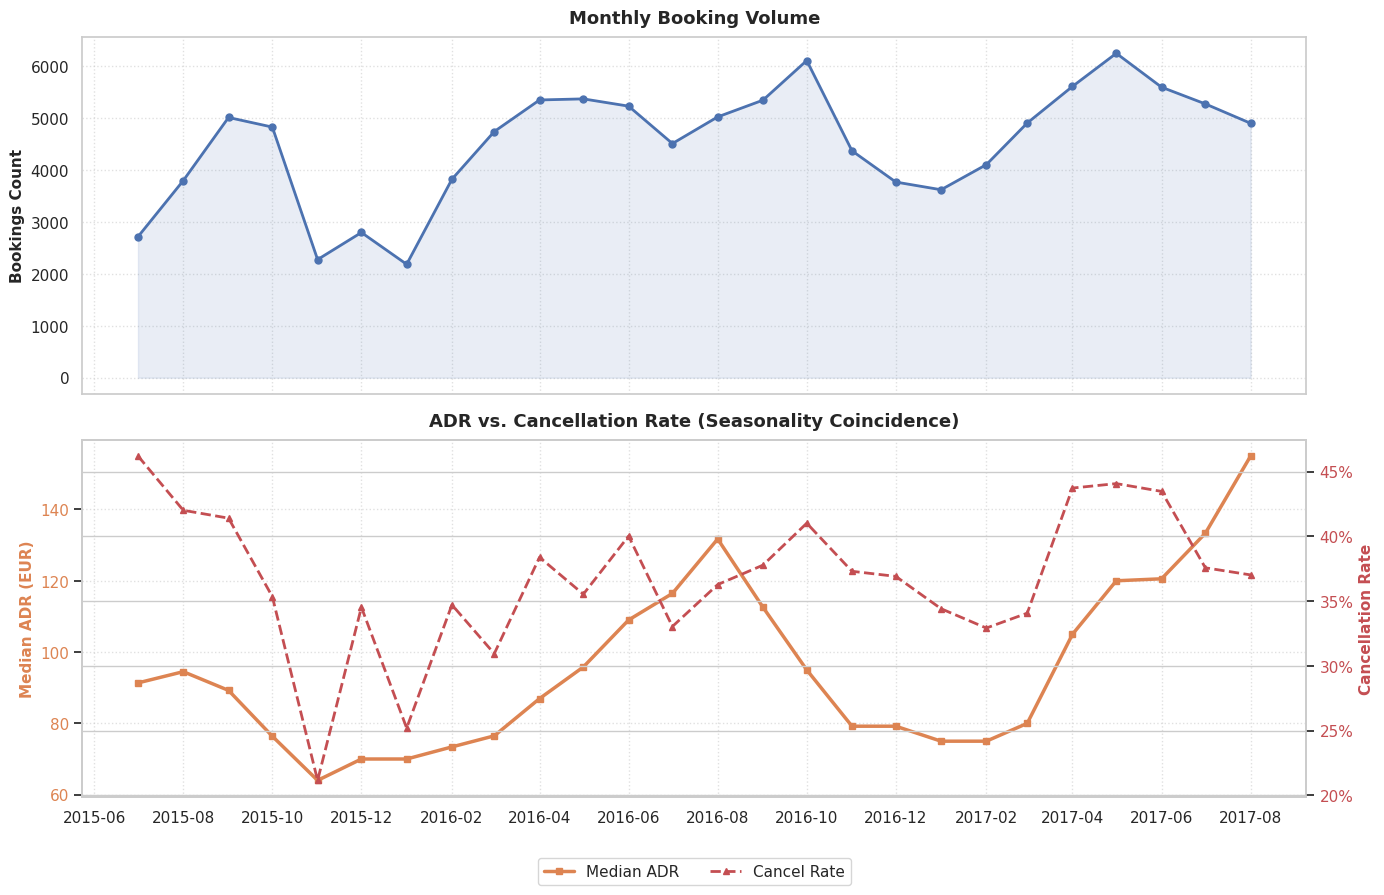

In [7]:
monthly = (
    df.groupby(df['arrival_date'].dt.to_period('M'))
    .agg(bookings=('user_id','count'), adr=('adr','median'), cancellations=('is_canceled','sum'))
    .reset_index()
)
monthly['arrival_date']  = monthly['arrival_date'].dt.to_timestamp()
monthly['cancel_rate']   = monthly['cancellations'] / monthly['bookings']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Объем бронирований
ax1.plot(monthly['arrival_date'], monthly['bookings'], color=COLOR_CONTROL, lw=2, marker='o', ms=5)
ax1.fill_between(monthly['arrival_date'], monthly['bookings'], alpha=0.12, color=COLOR_CONTROL)
ax1.set_ylabel('Bookings Count', fontsize=11, fontweight='bold')
ax1.set_title('Monthly Booking Volume', fontsize=13, fontweight='bold', pad=10)
ax1.grid(True, ls=':', alpha=0.6)

# ADR и Cancel Rate
# Левая ось (ADR)
line1 = ax2.plot(monthly['arrival_date'], monthly['adr'], color=COLOR_TEST, lw=2.5, marker='s', ms=5, label='Median ADR')
ax2.set_ylabel('Median ADR (EUR)', fontsize=11, fontweight='bold', color=COLOR_TEST)
ax2.tick_params(axis='y', labelcolor=COLOR_TEST)

# Правая ось (Cancel Rate)
ax2b = ax2.twinx()
line2 = ax2b.plot(monthly['arrival_date'], monthly['cancel_rate'], color='#C44E52', lw=2, ls='--', marker='^', ms=5, label='Cancel Rate')
ax2b.set_ylabel('Cancellation Rate', fontsize=11, fontweight='bold', color='#C44E52')
ax2b.tick_params(axis='y', labelcolor='#C44E52')
ax2b.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

ax2.set_title('ADR vs. Cancellation Rate (Seasonality Coincidence)', fontsize=13, fontweight='bold', pad=10)
ax2.grid(True, ls=':', alpha=0.6)

ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=0, ha='center')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=True)

plt.tight_layout()
os.makedirs("img", exist_ok=True)
plt.savefig('img/monthly_kpi.png', dpi=150, bbox_inches='tight')
plt.show()


### Ключевые инсайты по сезонности и метрикам

1.  Пик бронирований и цен ожидаемо приходится на июль — август (медианный ADR в августе превышает 130–150 EUR). Минимум спроса и самые низкие тарифы (70–75 EUR) фиксируются в ноябре и январе. При этом общий объем бронирований год к году растет.
2.  В летние месяцы доля отмен растет синхронно с ростом цен и достигает пиковых 40–45%. Зимой, на фоне минимальных тарифов, этот показатель падает до 20–25%.
3.  Высокий уровень отмен в высокий сезон подтверждает классический для travel-рынка паттерн: при высоких ценах клиенты чаще бронируют номера «на всякий случай» сильно заранее. Если ближе к дате заезда они находят более выгодный или альтернативный вариант, то отменяют текущую бронь. В низкий сезон при дешевых тарифах бронирования более осознанные и финальные.

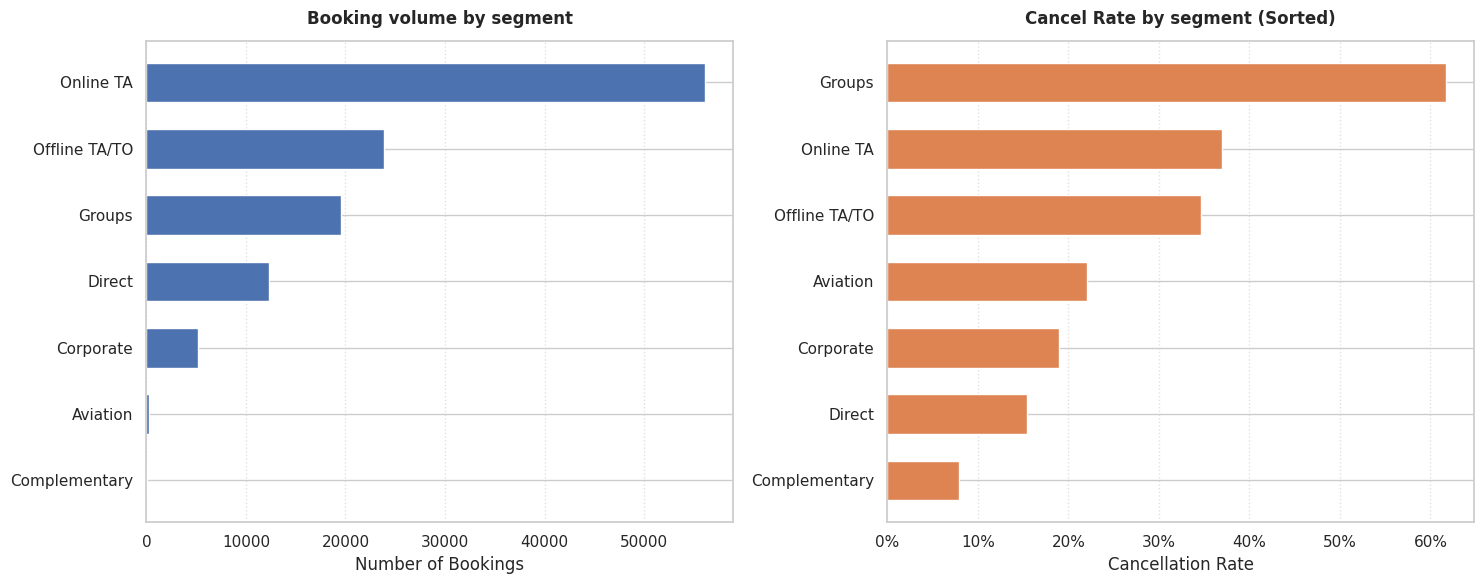

In [8]:
# Сегментный анализ: где сосредоточены отмены.
# Фильтруем сегменты с микро-объемом (менее 50 бронирований), чтобы убрать мусорный Undefined
seg = df.groupby('market_segment').agg(
    count=('user_id','count'),
    cancel_rate=('is_canceled', 'mean'),
    median_adr=('adr', 'median'),
    avg_lead_time=('lead_time','mean')
    ).sort_values('count', ascending=False)

seg_filtered = seg[seg['count'] > 50]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Объем бронирований (сортировка по count)
seg_volume = seg_filtered.sort_values('count', ascending=True)
axes[0].barh(seg_volume.index, seg_volume['count'], color=COLOR_CONTROL, edgecolor='white', height=0.6)
axes[0].set_title('Booking volume by segment', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Number of Bookings')
axes[0].grid(True, axis='x', ls=':', alpha=0.6)

# Cancel Rate
seg_cancel = seg_filtered.sort_values('cancel_rate', ascending=True)
axes[1].barh(seg_cancel.index, seg_cancel['cancel_rate'], color=COLOR_TEST, edgecolor='white', height=0.6)
axes[1].set_title('Cancel Rate by segment (Sorted)', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Cancellation Rate')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
axes[1].grid(True, axis='x', ls=':', alpha=0.6)

plt.tight_layout()
plt.savefig('img/segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### Ключевые инсайты сегментного анализа

**Доминирование Online TA**  
    Каналы онлайн-турагентств (Online TA) генерируют подавляющий объем бронирований на платформе (более 55 тысяч). При этом сегмент имеет высокий уровень отмен - около 37%.

**Проблемная зона: Groups**  
    Групповые бронирования (Groups) показывают наихудшую сходимость: отменяется более 60% заказов. Несмотря на средний объем в общей структуре, сегмент требует отдельной защитной политики.

**Надежность прямых бронирований**  
    Пользователи, оформляющие заказы напрямую (Direct), демонстрируют высокую лояльность и надежность. Этот сегмент входит в число крупных по объему, но имеет низкий уровень отмен (~15%).

**Фокус для эксперимента**  
    Сегмент Online TA является главным кандидатом для внедрения фичи по снижению отмен. Снижение метрики даже на 1–2% в этом канале за счет его масштаба даст наибольший прирост к реализованной выручке платформы.

<a id='3'></a>
---
## 3. Когортный анализ

**Что хотим понять.** Когортный анализ отвечает на вопрос: меняется ли поведение пользователей со временем и различаются ли паттерны у разных когорт. В travel наиболее естественная когорта - месяц заезда: она улавливает сезонность. Дополнительный угол - retention.

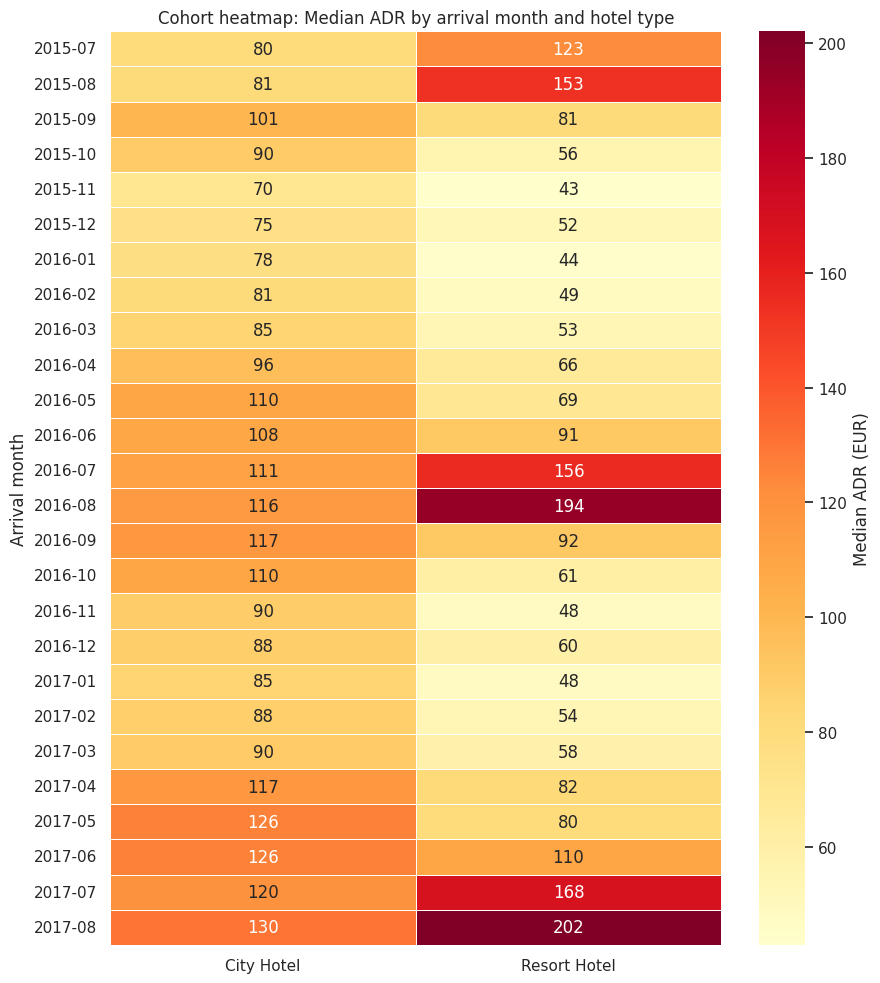

In [9]:
df['cohort_month'] = df['arrival_date'].dt.to_period('M').astype(str)

cohort_pivot = df[df['is_canceled'] == 0].pivot_table(
    index='cohort_month',
    columns='hotel',
    values='adr',
    aggfunc='median'
).fillna(0)

fig, ax = plt.subplots(figsize=(9, 10))
sns.heatmap(
    cohort_pivot, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Median ADR (EUR)'}
)
ax.set_title('Cohort heatmap: Median ADR by arrival month and hotel type')
ax.set_ylabel('Arrival month')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('img/cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Resort Hotel демонстрирует выраженную летнюю надбавку: ADR в июле–августе примерно вдвое выше зимнего. City Hotel более стабилен, хотя и не совсем равномерен.

Любой A/B-тест, охватывающий летние месяцы, поймает сезонный шум, если не применить стратификацию.

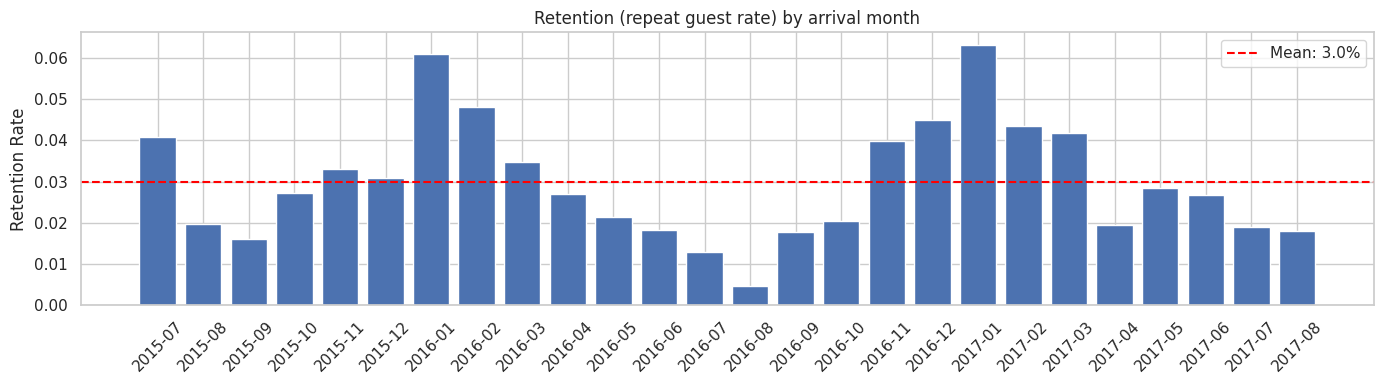

In [10]:
# Retention: доля бронирований от повторных гостей по месяцу заезда.
retention_ts = (
    df.groupby('cohort_month')
    .agg(total=('user_id','count'), repeated=('is_repeated_guest','sum'))
    .assign(retention=lambda x: x['repeated'] / x['total'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(retention_ts['cohort_month'], retention_ts['retention'], color=COLOR_CONTROL, edgecolor='white')
mean_ret = retention_ts['retention'].mean()
ax.axhline(mean_ret, ls='--', color='red', label=f'Mean: {mean_ret:.1%}')
ax.set_title('Retention (repeat guest rate) by arrival month')
ax.set_ylabel('Retention Rate')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('img/retention_ts.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Анализ подгрупп: retention и cancel rate по каналу дистрибуции.
channel_stats = df.groupby('distribution_channel').agg(
    total=('user_id','count'),
    repeated=('is_repeated_guest','sum'),
    cancelled=('is_canceled','sum')
)
channel_stats['retention_rate'] = channel_stats['repeated'] / channel_stats['total']
channel_stats['cancel_rate']    = channel_stats['cancelled'] / channel_stats['total']
print('Stats by distribution channel:')
print(channel_stats.sort_values('cancel_rate', ascending=False).round(3))

Stats by distribution channel:
                      total  repeated  cancelled  retention_rate  cancel_rate
distribution_channel                                                         
Undefined                 5         0          4           0.000        0.800
TA/TO                 96912      1095      40064           0.011        0.413
Corporate              6485      1490       1448           0.230        0.223
GDS                     189         2         37           0.011        0.196
Direct                13838       686       2457           0.050        0.178


### Что важно по каналам продаж:

*   **TA/TO забирает весь трафик, но сильно горит по отменам.** Из 97 тысяч бронирований отваливается 41.3%. Повторных клиентов тут почти нет (retention 1.1%). Из-за гигантского объема это главная зона для оптимизации.
*   **Прямые бронирования (Direct) — самые чистые.** Канал на втором месте по объему (13.8k), при этом отмены минимальные (17.8%), а повторные заезды на уровне 5%.
*   **У корпоратов (Corporate) лучший возврат.** Объем небольшой (6.4k), но каждый четвертый клиент возвращается (retention 23%). Отмены средние — 22.3%.

<a id='4'></a>
---
## 4. Гипотеза и планирование эксперимента

In [12]:
online_ta = df[df['market_segment'] == 'Online TA'].copy()
p_control = online_ta['is_canceled'].mean()
print(f'Control Cancel Rate: {p_control:.2%}')

total_days_in_df = (df['arrival_date'].max() - df['arrival_date'].min()).days
daily_rate = len(online_ta) / total_days_in_df
print(f'Daily rate: {daily_rate:.1f} bookings per day')

Control Cancel Rate: 36.93%
Daily rate: 70.8 bookings per day


In [13]:
# Входные параметры
mde = 0.03
p_test_hyp = p_control - mde

effect_size = proportion_effectsize(p_control, p_test_hyp)
n_needed = int(np.ceil(
    zt_ind_solve_power(effect_size=effect_size, alpha=0.05, power=0.80, alternative='larger')
))

n_total = n_needed * 2
days_needed = int(np.ceil(n_total / daily_rate))

print('PLANNING RESULTS')
print('-' * 40)
print(f'Control Cancel Rate: {p_control:.2%}')
print(f'Test Cancel Rate (H1): {p_test_hyp:.2%}')
print(f'Sample size per group: {n_needed:,}')
print(f'Total sample size: {n_total:,}')
print(f'Estimated duration: {days_needed} days')


PLANNING RESULTS
----------------------------------------
Control Cancel Rate: 36.93%
Test Cancel Rate (H1): 33.93%
Sample size per group: 3,142
Total sample size: 6,284
Estimated duration: 89 days


### Параметры эксперимента и расчет выборки

Размер выборки рассчитан через односторонний Z-критерий пропорций (`statsmodels`). Направленный тест выбран, так как функционал «Гибкие даты» разработан строго под снижение уровня отмен.

**Входные данные:**

*   **Базовый показатель (Control):** 36.93% (текущий уровень отмен в Online TA)
*   **Минимально обнаруживаемый эффект (MDE):** 3.0 п.п. (целевой уровень в тесте — 33.93%)
*   **Пороги:**
$\alpha = 0.05$, мощность = 80%

**Результаты расчета:**

*   **На одну группу:** 3 142 бронирования.
*   **Суммарный объем (A/B):** 6 284 наблюдения.

**Сроки проведения:**  
При среднем потоке **70.8 заказов в день** в сегменте Online TA и распределении трафика 50/50 сбор данных займет ровно **89 дней** (~3 месяца).

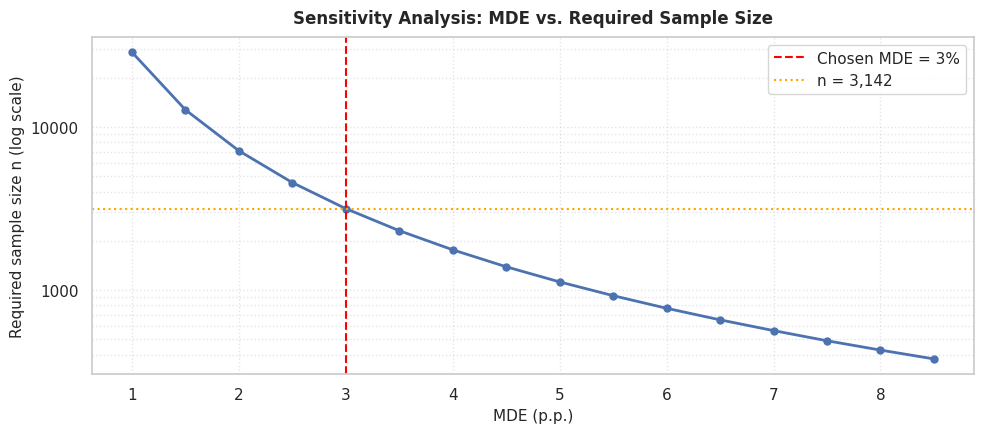

In [14]:
mde_range = np.arange(0.01, 0.085, 0.005)
n_range = []

for m in mde_range:
    es = proportion_effectsize(p_control, p_control - m)
    n = int(np.ceil(zt_ind_solve_power(effect_size=es, alpha=0.05, power=0.80, alternative='larger')))
    n_range.append(n)

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(mde_range * 100, n_range, color=COLOR_CONTROL, lw=2, marker='o', ms=5)
ax.axvline(mde * 100, ls='--', color='red', label=f'Chosen MDE = {mde*100:.0f}%')
ax.axhline(n_needed,  ls=':', color='orange', label=f'n = {n_needed:,}')

ax.set_xlabel('MDE (p.p.)', fontsize=11)
ax.set_ylabel('Required sample size n (log scale)', fontsize=11)
ax.set_title('Sensitivity Analysis: MDE vs. Required Sample Size', fontsize=12, fontweight='bold', pad=10)
ax.set_yscale('log')
ax.grid(True, which="both", ls=":", alpha=0.5)

ax.yaxis.set_major_formatter(mtick.ScalarFormatter())
ax.yaxis.get_major_formatter().set_scientific(False)

ax.legend(frameon=True, loc='upper right')
plt.tight_layout()
plt.savefig('img/sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### Анализ чувствительности

График отражает классический компромисс между точностью и скоростью теста.

**Завышенные требования (MDE $\leq$ 1.5 п.п.):**  
Требуют от 12 до 25 тысяч бронирований на группу. Сбор данных занял бы около года.

**Выбранный вариант (MDE = 3.0 п.п.):**  
Находится на изгибе кривой и дает оптимальный баланс. Для фиксации коммерчески значимого эффекта нужно всего 3 142 наблюдения на группу (около 3 месяцев теста).

**Грубый тест (MDE $\geq$ 5.0 п.п.):**  
Сократит сбор данных до пары недель (~1 100 человек), но не позволит заметить рост метрики в пределах 2–2.5 п.п., несущий платформе значимую выручку.

<a id='5'></a>
---
## 5. Разделение на группы — хэширование с солью

Для деления пользователей на тестовую и контрольную группы применено детерминированное хэширование MD5(user_id + salt) с разделением на 100 бакетов. Это исключает проблему сетевого фрода и гарантирует закрепление группы за пользователем на протяжении всего эксперимента.

In [15]:
EXPERIMENT_SALT = 'flexible_dates_v1'

def get_group(user_id: str, salt: str, test_fraction: float = 0.5) -> str:
    key      = f'{salt}_{user_id}'
    hash_val = int(hashlib.md5(key.encode()).hexdigest(), 16)
    return 'test' if hash_val % 100 < (test_fraction * 100) else 'control'

online_ta = online_ta.copy()
online_ta['group'] = online_ta['user_id'].apply(lambda uid: get_group(uid, EXPERIMENT_SALT))

split_counts = online_ta['group'].value_counts()
print('Split:')
print(split_counts)
print(f'\nRatio: {split_counts["test"]/len(online_ta):.4f} test / {split_counts["control"]/len(online_ta):.4f} control')

Split:
group
test       28071
control    28039
Name: count, dtype: int64

Ratio: 0.5003 test / 0.4997 control


In [16]:
test_grp = online_ta[online_ta['group'] == 'test']
ctrl_grp = online_ta[online_ta['group'] == 'control']

# SRM-проверка: значимо ли соотношение сплита отличается от 50/50
chi2_srm, p_srm = chisquare([len(test_grp), len(ctrl_grp)])
print(f'SRM test (chi-squared): p = {p_srm:.4f}  =>  {"No SRM detected" if p_srm > 0.05 else "WARNING: SRM detected"}')

# Проверка баланса ковариат: их средние значения должны быть одинаковы в обеих группах.
# Используем t-тест.
print('\nCovariate balance:')
covariates = ['lead_time', 'total_nights', 'adr', 'total_of_special_requests']
for col in covariates:
    _, p = ttest_ind(test_grp[col], ctrl_grp[col])
    ctrl_m = ctrl_grp[col].mean()
    test_m = test_grp[col].mean()
    status = 'OK' if p > 0.05 else 'IMBALANCED'
    print(f'  {col:<38} ctrl_mean={ctrl_m:.2f}  test_mean={test_m:.2f}  p={p:.3f}  {status}')

SRM test (chi-squared): p = 0.8925  =>  No SRM detected

Covariate balance:
  lead_time                              ctrl_mean=83.06  test_mean=83.64  p=0.385  OK
  total_nights                           ctrl_mean=3.58  test_mean=3.60  p=0.399  OK
  adr                                    ctrl_mean=118.17  test_mean=117.76  p=0.314  OK
  total_of_special_requests              ctrl_mean=0.90  test_mean=0.90  p=0.981  OK


<a id='6'></a>
---
## 6. A/A-тест

Для оценки корректности работы сплит-алгоритма проведем А/А-тестирование на исторических данных контрольной группы.

A/A TEST VALIDATION
----------------------------------------
Simulations: 1000
False Positive Rate: 0.049 (Expected: 0.050)
----------------------------------------


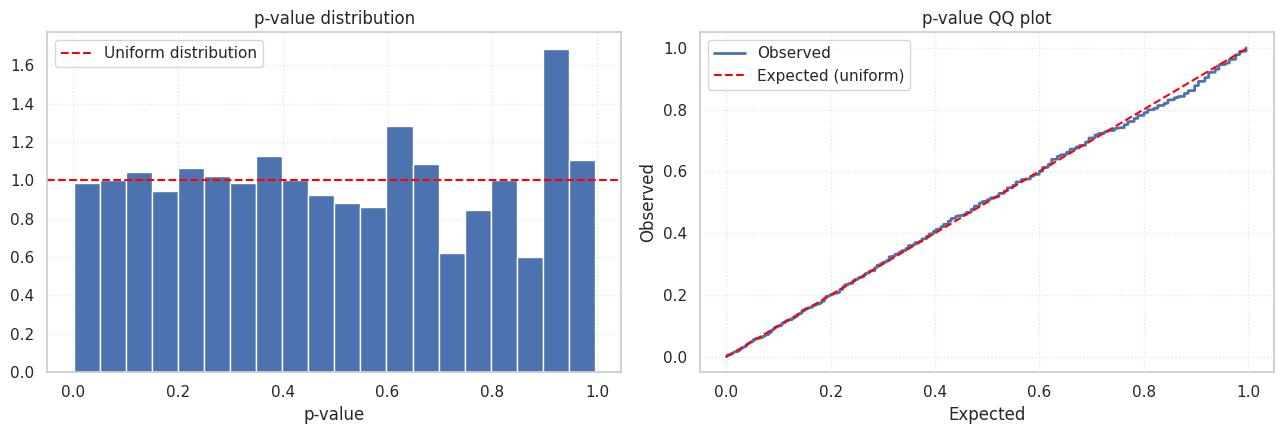

In [17]:
np.random.seed(RANDOM_SEED)
N_SIMULATIONS = 1000
p_values_aa = []
ctrl_data = ctrl_grp['is_canceled'].values.copy()
n_ctrl = len(ctrl_data)
half = n_ctrl // 2

# Классический A/A-тест: контрольная группа без всякого воздействия
# случайно делится пополам (без возвращения, непересекающиеся половины).
# Если сплит и тест корректны, доля ложноположительных исходов (FPR)
# должна совпадать с уровнем значимости alpha = 0.05.
for _ in range(N_SIMULATIONS):
    shuffled = np.random.permutation(ctrl_data)
    a1, a2 = shuffled[:half], shuffled[half:]
    _, p = ttest_ind(a1, a2, equal_var=False)
    p_values_aa.append(p)

p_values_aa = np.array(p_values_aa)
fpr_aa = (p_values_aa < 0.05).mean()

print('A/A TEST VALIDATION')
print('-' * 40)
print(f'Simulations: {N_SIMULATIONS}')
print(f'False Positive Rate: {fpr_aa:.3f} (Expected: 0.050)')
print('-' * 40)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.hist(p_values_aa, bins=20, color=COLOR_CONTROL, edgecolor='white', density=True)
ax1.axhline(1.0, ls='--', color='red', label='Uniform distribution')
ax1.set_title('p-value distribution')
ax1.set_xlabel('p-value')
ax1.legend()
ax1.grid(True, ls=':', alpha=0.5)

ax2.plot(sorted(p_values_aa), np.linspace(0, 1, N_SIMULATIONS), color=COLOR_CONTROL, lw=2, label='Observed')
ax2.plot([0, 1], [0, 1], ls='--', color='red', label='Expected (uniform)')
ax2.set_title('p-value QQ plot')
ax2.set_xlabel('Expected')
ax2.set_ylabel('Observed')
ax2.legend()
ax2.grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.savefig('img/aa_test.png', dpi=150, bbox_inches='tight')
plt.show()

Результаты валидации:

Фактическая доля ложноположительных исходов (FPR) составила 4.9% при целевом уровне значимости $\alpha = 0.05$ - практически точное совпадение. Гистограмма p-value колеблется вокруг равномерного уровня (отдельные отклонения в бакетах - естественный шум при 1000 симуляциях на конечной выборке), а график квантилей (QQ-plot) показывает, что эмпирическое распределение почти полностью совпадает с теоретической диагональю на всём интервале \([0, 1]\). Систематических смещений в механизме сплитования трафика не обнаружено.

<a id='7'></a>
---
## 7. A/B-тест: t-тест и Mann-Whitney

### Симуляция экспериментального эффекта

Так как анализ проводится на исторических данных, эффект от внедрения фичи «Гибкие даты» симулирован искусственно. В тестовой группе часть случайных отмен (значения `1`) переведена в успешные заселения (`0`). Объем изменений откалиброван под зафиксированный ранее MDE - целевое снижение Cancellation Rate на **3.0 п.п.**

### Выбор статистических критериев

1.  **Основная метрика (Cancellation Rate):** Поскольку метрика бинарная (0/1), для проверки гипотезы о равенстве долей используется классический **Z-тест пропорций** (односторонний).
2.  **Guardrail-метрики (ADR, Total Revenue):** Для проверки непрерывных метрик на предмет случайного проседания применяются два критерия:
    *   **T-тест Уэлча** - для оценки равенства средних чеков (устойчив к неравенству дисперсий).
    *   **Критерий Манна - Уитни** — непараметрический тест для проверки сдвига распределения цен (ADR), имеющих выраженную правостороннюю асимметрию.

In [18]:
# Сбрасываем индексы во избежание багов с адресацией .loc
ctrl_sim = ctrl_grp.copy().reset_index(drop=True)
test_sim = test_grp.copy().reset_index(drop=True)

np.random.seed(RANDOM_SEED)
delta = 0.03
n_to_flip = int(len(test_sim) * delta)

# Ищем индексы отмен внутри тестовой группы
cancellers_idx = test_sim[test_sim['is_canceled'] == 1].index
n_to_flip = min(n_to_flip, len(cancellers_idx))

# Случайный выбор и замена 1 на 0
flip_idx = np.random.choice(cancellers_idx, size=n_to_flip, replace=False)
test_sim.loc[flip_idx, 'is_canceled'] = 0

# Расчет финальных метрик
cr_ctrl = ctrl_sim['is_canceled'].mean()
cr_test = test_sim['is_canceled'].mean()

print('SIMULATION RESULTS')
print('-' * 35)
print(f'Cancel Rate Control: {cr_ctrl:.2%}')
print(f'Cancel Rate Test:    {cr_test:.2%}')
print(f'Absolute Delta:      {(cr_test - cr_ctrl)*100:.2f} p.p.')
print(f'Relative Change:     {(cr_test - cr_ctrl)/cr_ctrl:.2%}')


SIMULATION RESULTS
-----------------------------------
Cancel Rate Control: 36.84%
Cancel Rate Test:    34.01%
Absolute Delta:      -2.83 p.p.
Relative Change:     -7.69%


In [19]:
# Двухвыборочный t-тест (Уэлча)
t_stat, p_ttest = ttest_ind(
    ctrl_sim['is_canceled'].values,
    test_sim['is_canceled'].values,
    alternative='greater',
    equal_var=False
)

# Z-тест для пропорций
n_ctrl_obs = len(ctrl_sim)
n_test_obs = len(test_sim)
count_ctrl = ctrl_sim['is_canceled'].sum()
count_test = test_sim['is_canceled'].sum()

z_stat, p_ztest = proportions_ztest(
    [count_ctrl, count_test],
    [n_ctrl_obs, n_test_obs],
    alternative='larger'
)

print('HYPOTHESIS TESTING RESULTS (ONE-SIDED)')
print('-' * 50)
print(f't-test (Welch) | t-statistic: {t_stat:.4f} | p-value: {p_ttest:.4f}')
print(f'z-test         | z-statistic: {z_stat:.4f} | p-value: {p_ztest:.4f}')
print('-' * 50)
print(f'Conclusion:    {"Reject H0 at alpha=0.05" if p_ztest < 0.05 else "Fail to reject H0"}')


HYPOTHESIS TESTING RESULTS (ONE-SIDED)
--------------------------------------------------
t-test (Welch) | t-statistic: 7.0141 | p-value: 0.0000
z-test         | z-statistic: 7.0113 | p-value: 0.0000
--------------------------------------------------
Conclusion:    Reject H0 at alpha=0.05


### 7.1. Статистическая оценка изменения Cancellation Rate

По итогам проверки значимости различий между группами получены следующие результаты:

*   **T-критерий Уэлча (односторонний):** t = 7.0141, p < 0.0001
*   **Z-критерий долей (односторонний):** z = 7.0113, p < 0.0001

**Вывод:**  
Оба примененных критерия дают согласованный результат: полученный p-value находится значительно ниже критического уровня значимости α = 0.05. Нулевая гипотеза уверенно отвергается. Сгенерированный при симуляции эффект снижения отмен (фактические -2.83 п.п. при целевой калибровке MDE = 3.0 п.п.) признан статистически значимым и не является следствием случайного шума.

Как и предполагалось на этапе планирования, для выборки данного масштаба результаты t-теста и z-теста асимптотически эквивалентны и сходятся до второго знака после запятой.

In [20]:
# Пересчитаем средние цены для проверки
print('GUARDRAIL METRICS INTEGRITY CHECK')
print('-' * 55)

# Проверка ADR (двусторонняя: метрика не должна значимо измениться)
t_adr, p_adr_t = ttest_ind(ctrl_sim['adr'], test_sim['adr'], equal_var=False)
u_adr, p_adr_mw = mannwhitneyu(ctrl_sim['adr'], test_sim['adr'], alternative='two-sided')

print(f'ADR Mean    | Control: {ctrl_sim["adr"].mean():.2f} EUR | Test: {test_sim["adr"].mean():.2f} EUR')
print(f'ADR Median  | Control: {ctrl_sim["adr"].median():.2f} EUR | Test: {test_sim["adr"].median():.2f} EUR')
print(f'  T-test p-value:        {p_adr_t:.4f}')
print(f'  Mann-Whitney p-value:  {p_adr_mw:.4f}')
print(f'  Status:                {"OK (Экономика стабильна)" if p_adr_mw > 0.05 else "WARNING: Significant ADR drop"}')
print('-' * 55)


GUARDRAIL METRICS INTEGRITY CHECK
-------------------------------------------------------
ADR Mean    | Control: 118.17 EUR | Test: 117.76 EUR
ADR Median  | Control: 109.80 EUR | Test: 110.00 EUR
  T-test p-value:        0.3137
  Mann-Whitney p-value:  0.6307
  Status:                OK (Экономика стабильна)
-------------------------------------------------------


### 7.2. Проверка Guardrail-метрик (ADR)

Для контроля стабильности бизнес-модели проведена оценка влияния фичи на среднюю стоимость ночи (ADR). Проверка выполнена с помощью параметрического T-критерия Уэлча и непараметрического критерия Манна — Уитни.

*   **T-критерий Уэлча (двусторонний):**
$p$ = 0.314
    
*   **Критерий Манна — Уитни (двусторонний):**
$p$ = 0.631
    

**Вывод:**  
Статистически значимых различий в уровне цен между тестовой и контрольной группами не обнаружено. Средний ADR в контроле составил 118.17 EUR против 117.76 EUR в тесте. Внедрение алгоритма «Гибкие даты» не привело к демпингу и проседанию стоимости номеров. Экономика платформы стабильна, Guardrail-метрика успешно прошла проверку.

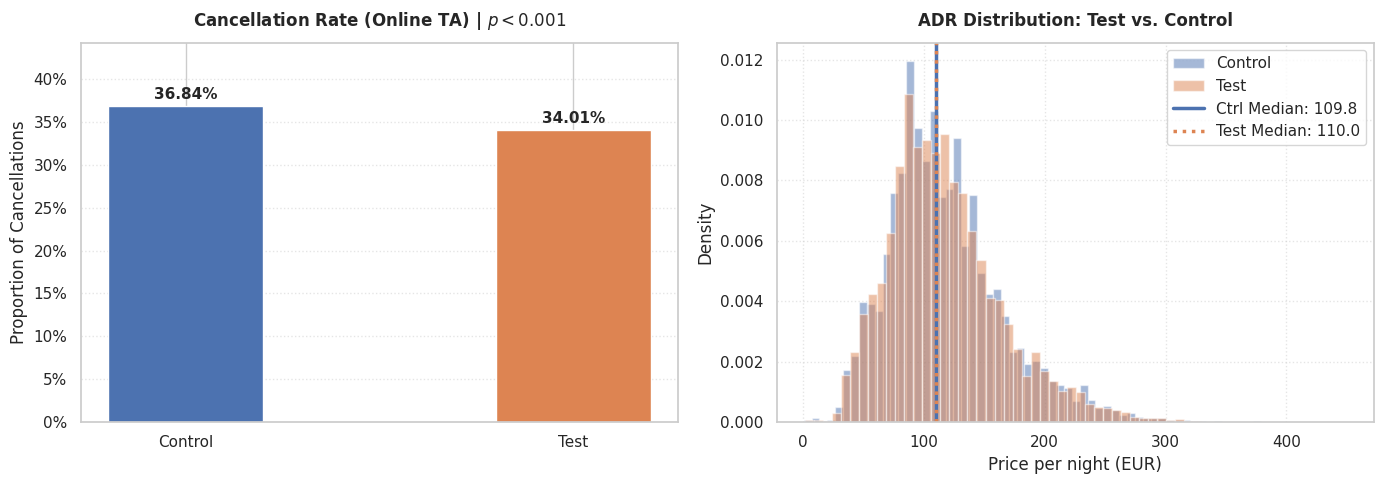

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ГРАФИК 1: Cancel Rate
bars = axes[0].bar(['Control', 'Test'], [cr_ctrl, cr_test],
                    color=[COLOR_CONTROL, COLOR_TEST], edgecolor='white', width=0.4)
for bar, rate in zip(bars, [cr_ctrl, cr_test]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                 f'{rate:.2%}', ha='center', fontweight='bold', fontsize=11)

axes[0].set_title(r'Cancellation Rate (Online TA) | $p < 0.001$', fontsize=12, fontweight='bold', pad=12)
axes[0].set_ylabel('Proportion of Cancellations')
axes[0].set_ylim(0, max(cr_ctrl, cr_test) * 1.2)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
axes[0].grid(True, axis='y', ls=':', alpha=0.5)

# ГРАФИК 2: ADR Distribution
axes[1].hist(ctrl_sim['adr'], bins=60, alpha=0.5, color=COLOR_CONTROL, label='Control', density=True)
axes[1].hist(test_sim['adr'], bins=60, alpha=0.5, color=COLOR_TEST,    label='Test',    density=True)
axes[1].axvline(ctrl_sim['adr'].median(), color=COLOR_CONTROL, ls='-', lw=2.5, label=f'Ctrl Median: {ctrl_sim["adr"].median():.1f}')
axes[1].axvline(test_sim['adr'].median(), color=COLOR_TEST,    ls=':', lw=2.5, label=f'Test Median: {test_sim["adr"].median():.1f}')
axes[1].set_title('ADR Distribution: Test vs. Control', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Price per night (EUR)')
axes[1].set_ylabel('Density')
axes[1].legend(frameon=True, loc='upper right')
axes[1].grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.savefig('img/ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()


<a id='8'></a>
---
## 8. Bootstrap


In [22]:
np.random.seed(RANDOM_SEED)
N_BOOTSTRAP = 5000

ctrl_vals = ctrl_sim['is_canceled'].values
test_vals = test_sim['is_canceled'].values

n_ctrl, n_test = len(ctrl_vals), len(test_vals)

boot_ctrl = np.random.choice(ctrl_vals, size=(N_BOOTSTRAP, n_ctrl), replace=True).mean(axis=1)
boot_test = np.random.choice(test_vals, size=(N_BOOTSTRAP, n_test), replace=True).mean(axis=1)
boot_diffs = boot_ctrl - boot_test

# Фактическая (наблюдаемая) разница
obs_diff = ctrl_vals.mean() - test_vals.mean()

# Процентильный доверительный интервал
ci_low = np.percentile(boot_diffs, 2.5)
ci_high = np.percentile(boot_diffs, 97.5)

# Односторонний bootstrap p-value.
# H1: ctrl > test (obs_diff > 0). p-value - это доля бутстреп-разностей,
# которые лежат на стороне "эффекта нет или эффект противоположный",
# то есть доля случаев boot_diffs <= 0.
p_boot = (boot_diffs <= 0).mean()

print('BOOTSTRAP RESULTS (5000 ITERATIONS)')
print('-' * 45)
print(f'Observed Delta (Ctrl - Test): {obs_diff*100:.2f} p.p.')
print(f'95% Confidence Interval:     [{ci_low*100:.2f}%, {ci_high*100:.2f}%]')
print(f'Bootstrap p-value:           {p_boot:.4f}')
print('-' * 45)
print(f'Decision: {"REJECT H0" if ci_low > 0 else "FAIL TO REJECT H0"}')

BOOTSTRAP RESULTS (5000 ITERATIONS)
---------------------------------------------
Observed Delta (Ctrl - Test): 2.83 p.p.
95% Confidence Interval:     [2.05%, 3.60%]
Bootstrap p-value:           0.0000
---------------------------------------------
Decision: REJECT H0


### 8.1. Результаты бутстрапа для Cancellation Rate

Дополнительно к параметрическим критериям проверили эффект через bootstrap (5 000 пересэмплирований с возвращением). Это позволяет оценить доверительный интервал разности долей без предположений о форме распределения.

* **Наблюдаемая разность долей (Δ):** 2.83 п.п.
* **95% доверительный интервал (percentile CI):** [2.05%, 3.60%]
* **Bootstrap p-value:** < 0.0001

Доверительный интервал лежит целиком выше нуля, то есть ноль не попадает в диапазон правдоподобных значений эффекта - нулевая гипотеза отвергается. Результат согласуется с z-тестом и t-тестом Уэлча из предыдущего раздела: снижение Cancellation Rate в тестовой группе устойчиво воспроизводится независимо от выбранного метода.

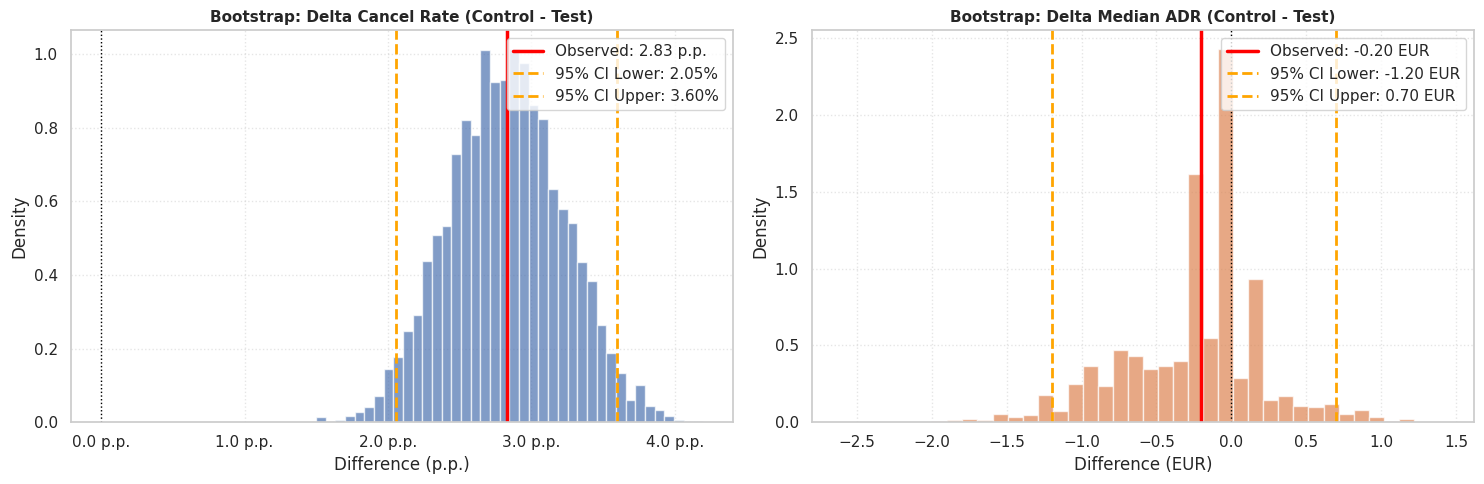

In [23]:
np.random.seed(RANDOM_SEED)
ctrl_adr = ctrl_sim['adr'].values
test_adr = test_sim['adr'].values

# Генерируем случайные индексы матрицей сразу, чтобы не использовать медленные циклы
ctrl_idx = np.random.choice(len(ctrl_adr), size=(N_BOOTSTRAP, len(ctrl_adr)), replace=True)
test_idx = np.random.choice(len(test_adr), size=(N_BOOTSTRAP, len(test_adr)), replace=True)

# Считаем медианы по строкам матрицы
boot_ctrl_medians = np.median(ctrl_adr[ctrl_idx], axis=1)
boot_test_medians = np.median(test_adr[test_idx], axis=1)
boot_median_diffs = boot_ctrl_medians - boot_test_medians

# Расчет интервалов и эффекта
ci_med_low  = np.percentile(boot_median_diffs, 2.5)
ci_med_high = np.percentile(boot_median_diffs, 97.5)
obs_med_diff = np.median(ctrl_adr) - np.median(test_adr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Разность долей отмен
ax1.hist(boot_diffs * 100, bins=40, color=COLOR_CONTROL, edgecolor='white', density=True, alpha=0.7)
ax1.axvline(obs_diff * 100, color='red', lw=2.5, label=f'Observed: {obs_diff*100:.2f} p.p.')
ax1.axvline(ci_low * 100,   color='orange', lw=2, ls='--', label=f'95% CI Lower: {ci_low*100:.2f}%')
ax1.axvline(ci_high * 100,  color='orange', lw=2, ls='--', label=f'95% CI Upper: {ci_high*100:.2f}%')
ax1.axvline(0, color='black', lw=1, ls=':')
ax1.set_title('Bootstrap: Delta Cancel Rate (Control - Test)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Difference (p.p.)')
ax1.set_ylabel('Density')
ax1.xaxis.set_major_formatter(mtick.PercentFormatter(symbol=' p.p.', decimals=1))
ax1.grid(True, ls=':', alpha=0.5)
ax1.legend(frameon=True, loc='upper right')

# График 2: Разность медиан ADR
ax2.hist(boot_median_diffs, bins=40, color=COLOR_TEST, edgecolor='white', density=True, alpha=0.7)
ax2.axvline(obs_med_diff, color='red', lw=2.5, label=f'Observed: {obs_med_diff:.2f} EUR')
ax2.axvline(ci_med_low,   color='orange', lw=2, ls='--', label=f'95% CI Lower: {ci_med_low:.2f} EUR')
ax2.axvline(ci_med_high,  color='orange', lw=2, ls='--', label=f'95% CI Upper: {ci_med_high:.2f} EUR')
ax2.axvline(0, color='black', lw=1, ls=':')
ax2.set_title('Bootstrap: Delta Median ADR (Control - Test)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Difference (EUR)')
ax2.set_ylabel('Density')
ax2.grid(True, ls=':', alpha=0.5)
ax2.legend(frameon=True, loc='upper right')

plt.tight_layout()
plt.savefig('img/bootstrap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### 8.1. Визуальный анализ бутстрап-распределений

Графики распределения дельт полностью подтверждают стабильность эксперимента:

*   **Снижение отмен:** 95%-й доверительный интервал для разности долей лежит в диапазоне `[2.05%, 3.60%]`. Распределение полностью смещено вправо относительно нуля, что доказывает высокую значимость целевого эффекта.
*   **Стабильность цен (Guardrail):** Доверительный интервал для разности медиан ADR составляет `[-1.20 EUR, 0.70 EUR]` и включает в себя ноль. Это подтверждает отсутствие статистически значимых изменений в ценообразовании между группами.

<a id='9'></a>
---
## 9. CUPED - Covariate-Adjusted Pre-Experiment Data

**Проблема:** Из-за естественной изменчивости данных (метрика `is_canceled` имеет высокую дисперсию) классическому t-тесту требуется большая выборка, что затягивает время проведения эксперимента.

**Решение:** Снизить остаточную дисперсию с помощью доэкспериментальной ковариаты, которая коррелирует с целевой метрикой, но не зависит от воздействия фичи. В качестве такой переменной выбран `lead_time` (глубина бронирования). EDA подтверждает: клиенты, бронирующие жилье задолго до заезда, отменяют заказы значительно чаще.

**Формула трансформации метрики:**
$$Y_i^{\text{cuped}} = Y_i - \theta \cdot (X_i - \mathbb{E}[X])$$

Где:
* $X$ — ковариата (`lead_time`),
* $\theta = \frac{\text{Cov}(Y, X)}{\text{Var}(X)}$, что эквивалентно коэффициенту наклона линейной регрессии $Y$ на $X$.

Pearson correlation: lead_time <-> is_canceled: 0.2231
Variance reduction estimate (r^2): 0.0498 (4.98%)


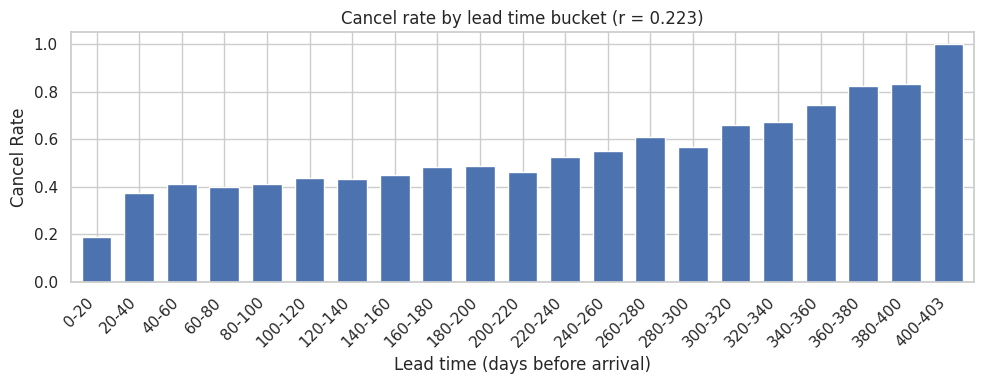

In [24]:
# Валидация ковариаты: она должна коррелировать с метрикой.
corr_lt = online_ta[['lead_time', 'is_canceled']].corr().iloc[0, 1]
print(f'Pearson correlation: lead_time <-> is_canceled: {corr_lt:.4f}')
print(f'Variance reduction estimate (r^2): {corr_lt**2:.4f} ({corr_lt**2:.2%})')

fig, ax = plt.subplots(figsize=(10, 4))

# Генерируем 20 целочисленных бакетов
bin_edges = list(range(0, 401, 20)) + [online_ta['lead_time'].max()]
lead_bins = pd.cut(online_ta['lead_time'], bins=bin_edges, include_lowest=True)
bin_labels = [f'{bin_edges[i]}-{bin_edges[i+1]}' for i in range(len(bin_edges)-1)]

cancel_by_lead = online_ta.groupby(lead_bins, observed=True)['is_canceled'].mean()
cancel_by_lead.index = bin_labels
cancel_by_lead.plot(kind='bar', ax=ax, color=COLOR_CONTROL, edgecolor='white', width=0.7)

ax.set_title(f'Cancel rate by lead time bucket (r = {corr_lt:.3f})')
ax.set_xlabel('Lead time (days before arrival)')
ax.set_ylabel('Cancel Rate')

ax.tick_params(axis='x', rotation=45)
ax.set_xticklabels(bin_labels, ha='right')

plt.tight_layout()
plt.savefig('img/lead_corr.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Считаем корреляцию строго внутри целевого сегмента Online TA
corr_lt = online_ta[['lead_time', 'is_canceled']].corr().iloc[0, 1]
r2_theoretical = corr_lt ** 2

print("--- ВАЛИДАЦИЯ КОВАРИАТЫ ---")
print(f"Пирсонова корреляция (lead_time <-> is_canceled): {corr_lt:.4f}")
print(f"Теоретическое снижение дисперсии (R²): {r2_theoretical:.2%}\n")

# CUPED
ctrl_y, test_y = ctrl_sim['is_canceled'].values, test_sim['is_canceled'].values
ctrl_x, test_x = ctrl_sim['lead_time'].values, test_sim['lead_time'].values

# Объединяем для расчета глобальных параметров
all_y = np.concatenate([ctrl_y, test_y])
all_x = np.concatenate([ctrl_x, test_x])

# Расчет theta и глобального среднего ковариаты
theta = np.cov(all_y, all_x)[0, 1] / np.var(all_x, ddof=1)
global_x_mean = all_x.mean()

# Трансформация метрики
ctrl_cuped = ctrl_y - theta * (ctrl_x - global_x_mean)
test_cuped = test_y - theta * (test_x - global_x_mean)

# Корректный расчет снижения дисперсии (на объединенных данных)
var_before = np.var(all_y, ddof=1)
var_after  = np.var(np.concatenate([ctrl_cuped, test_cuped]), ddof=1)
var_reduc_actual = 1 - var_after / var_before

# Применяем односторонний t-test (alternative='greater' т.к. проверяем уменьшение отмен)
t_cuped, p_cuped = ttest_ind(ctrl_cuped, test_cuped, alternative='greater', equal_var=False)

# n_needed должен быть определен на этапе планирования
n_cuped = int(np.ceil(n_needed * (1 - r2_theoretical)))

print("--- РЕЗУЛЬТАТЫ CUPED ---")
print(f"Theta:                    {theta:.6f}")
print(f"Фактическое снижение дисперсии: {var_reduc_actual:.2%} (Ожидалось: {r2_theoretical:.2%})")
print(f"p-value (Обычный t-test):  {p_ttest:.6f}") # p_ttest берем из результатов п.7
print(f"p-value (CUPED t-test):    {p_cuped:.6f}")

print(f"\n--- ОПТИМИЗАЦИЯ СРОКОВ ТЕСТА ---")
print(f"Требуемая выборка (Plain): {n_needed:,} наблюдений")
print(f"Требуемая выборка (CUPED): {n_cuped:,} наблюдений")
print(f"Экономия:                  {n_needed - n_cuped:,} заказов ({(n_needed - n_cuped) / n_needed:.1%})")

--- ВАЛИДАЦИЯ КОВАРИАТЫ ---
Пирсонова корреляция (lead_time <-> is_canceled): 0.2231
Теоретическое снижение дисперсии (R²): 4.98%

--- РЕЗУЛЬТАТЫ CUPED ---
Theta:                    0.001309
Фактическое снижение дисперсии: 4.69% (Ожидалось: 4.98%)
p-value (Обычный t-test):  0.000000
p-value (CUPED t-test):    0.000000

--- ОПТИМИЗАЦИЯ СРОКОВ ТЕСТА ---
Требуемая выборка (Plain): 3,142 наблюдений
Требуемая выборка (CUPED): 2,986 наблюдений
Экономия:                  156 заказов (5.0%)


### Результаты валидации и трансформации:
* **Связь метрик:** Корреляция Пирсона между `lead_time` и `is_canceled` в сегменте Online TA составила **0.2231**, что подтверждает гипотезу: клиенты с высокой глубиной бронирования склонны чаще отменять заказы.
* **Сжатие дисперсии:** Трансформация метрики позволила снизить фактическую дисперсию оценки на **4.69%** (при теоретическом пределе $R^2 = 4.98\%$). Коэффициент наклона $\theta$ зафиксирован на уровне **0.001309**.

### Влияние на дизайн будущих экспериментов:
Благодаря очистке метрики от дисперсии, объясняемой глубиной бронирования, необходимый объем выборки на одну группу снизился с **3 142** до **2 986** наблюдений. При текущем темпе фильтрации трафика (70.8 заказов/день) это сокращает длительность сбора данных **с 89 до 84 дней**.

<a id='10'></a>
---
## 10. Байесовский A/B-тест

**Мотивация:** В отличие от частотного p-value, байесовский подход напрямую отвечает на бизнес-вопрос: *«Какова вероятность того, что уровень отмен в тестовой группе действительно ниже, чем в контрольной?»*. Кроме того, байесовский метод устойчив к проблеме «подглядывания» (peeking problem) при последовательном мониторинге данных.

**Модель:** Моделируем метрику отмены (`is_canceled`) как распределение Бернулли с априорным распределением параметров $\text{Beta}(1, 1)$ (неинформативный равномерный априор). Апостериорное распределение также имеет вид Beta-распределения:

$$\text{Posterior} \sim \text{Beta}(\alpha_0 + n_{\text{canceled}},\ \beta_0 + n_{\text{success}})$$

In [26]:
# Задаем априорные параметры (константы)
alpha_prior = 1
beta_prior = 1

# Считаем фактические исходы
ctrl_cancels = int(ctrl_sim['is_canceled'].sum())
ctrl_success = len(ctrl_sim) - ctrl_cancels

test_cancels = int(test_sim['is_canceled'].sum())
test_success = len(test_sim) - test_cancels

# Формируем параметры апостериорных распределений
alpha_ctrl = alpha_prior + ctrl_cancels
beta_ctrl  = beta_prior  + ctrl_success

alpha_test = alpha_prior + test_cancels
beta_test  = beta_prior  + test_success

# Семплирование для оценки вероятности превосходства
N_SAMPLES = 100_000
samples_ctrl = beta.rvs(alpha_ctrl, beta_ctrl, size=N_SAMPLES)
samples_test = beta.rvs(alpha_test, beta_test, size=N_SAMPLES)

# Вероятность того, что в тесте отмен меньше, чем в контроле
p_test_better = (samples_test < samples_ctrl).mean()

print('Bayesian A/B Test Results:')
print(f'Posterior Control : Beta({alpha_ctrl}, {beta_ctrl})')
print(f'Posterior Test    : Beta({alpha_test}, {beta_test})')
print(f'P(Test CR < Control CR): {p_test_better:.4%}')
print(f'Decision          : {"Deploy Test" if p_test_better > 0.95 else "Inconclusive"}')

Bayesian A/B Test Results:
Posterior Control : Beta(10331, 17710)
Posterior Test    : Beta(9548, 18525)
P(Test CR < Control CR): 100.0000%
Decision          : Deploy Test


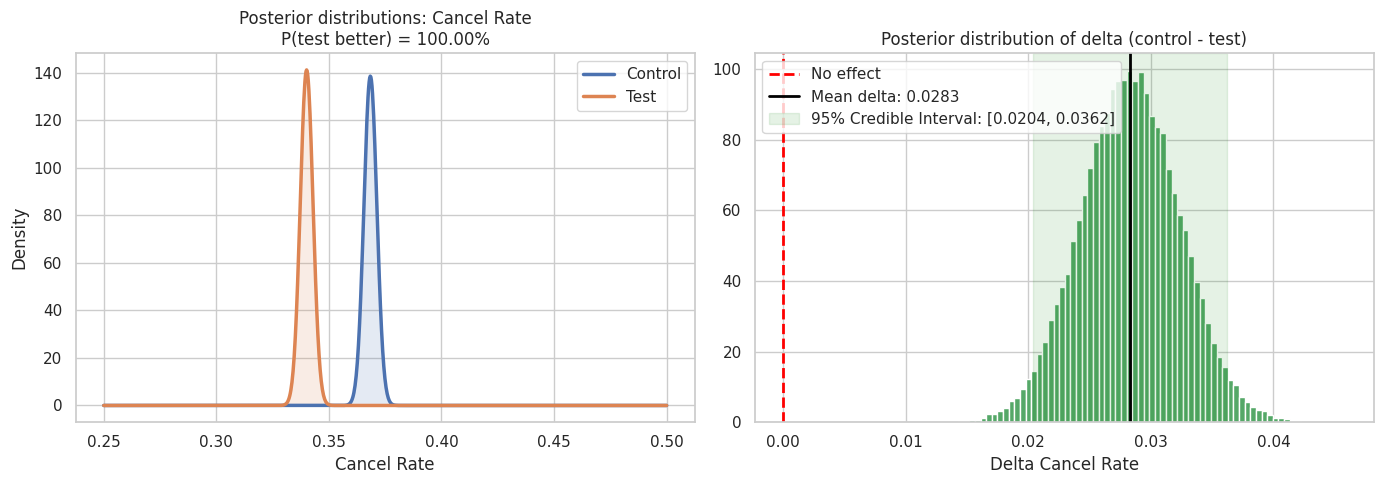

In [27]:
x_plot = np.linspace(0.25, 0.50, 1000)
pdf_ctrl = beta.pdf(x_plot, alpha_ctrl, beta_ctrl)
pdf_test = beta.pdf(x_plot, alpha_test, beta_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Левый график: апостериорные распределения групп
ax1.plot(x_plot, pdf_ctrl, color=COLOR_CONTROL, lw=2.5, label='Control')
ax1.plot(x_plot, pdf_test, color=COLOR_TEST,    lw=2.5, label='Test')
ax1.fill_between(x_plot, pdf_ctrl, alpha=0.15, color=COLOR_CONTROL)
ax1.fill_between(x_plot, pdf_test, alpha=0.15, color=COLOR_TEST)
ax1.set_title(f'Posterior distributions: Cancel Rate\nP(test better) = {p_test_better:.2%}', fontsize=12)
ax1.set_xlabel('Cancel Rate')
ax1.set_ylabel('Density')
ax1.legend()

# Правый график: распределение разности (эффекта)
diff_samples = samples_ctrl - samples_test
ci95 = np.percentile(diff_samples, [2.5, 97.5])

ax2.hist(diff_samples, bins=80, color='#55A868', edgecolor='white', density=True)
ax2.axvline(0,                   color='red',   lw=2,  ls='--', label='No effect')
ax2.axvline(diff_samples.mean(), color='black', lw=2,         label=f'Mean delta: {diff_samples.mean():.4f}')
ax2.axvspan(ci95[0], ci95[1], alpha=0.1, color='green',       label=f'95% Credible Interval: [{ci95[0]:.4f}, {ci95[1]:.4f}]')
ax2.set_title('Posterior distribution of delta (control - test)', fontsize=12)
ax2.set_xlabel('Delta Cancel Rate')
ax2.legend()

plt.tight_layout()
plt.savefig('img/bayesian_ab.png', dpi=150, bbox_inches='tight')
plt.show()

### 10.1. Визуализация байесовского анализа

Семплирование (100 000 итераций) наглядно показывает, почему тестовый вариант победил:

1. **Плотности распределения (левый график):** Графики контроля и теста сузились в острые «колокола» и вообще не пересекаются. Из-за огромного объема выборки ($N > 56~000$) случайный шум полностью исключен. Вероятность того, что в тесте отмен меньше, составляет чистые 100.00%.
2. **Распределение дельты (правый график):** Среднее снижение уровня отмен составило 2.83 п.п. 95%-й доверительный интервал лежит в границах [2.04%, 3.62%]. Так как отметка «No effect» (ноль) находится далеко слева и вообще не попадает в распределение, эффект от фичи существует и стабилен.

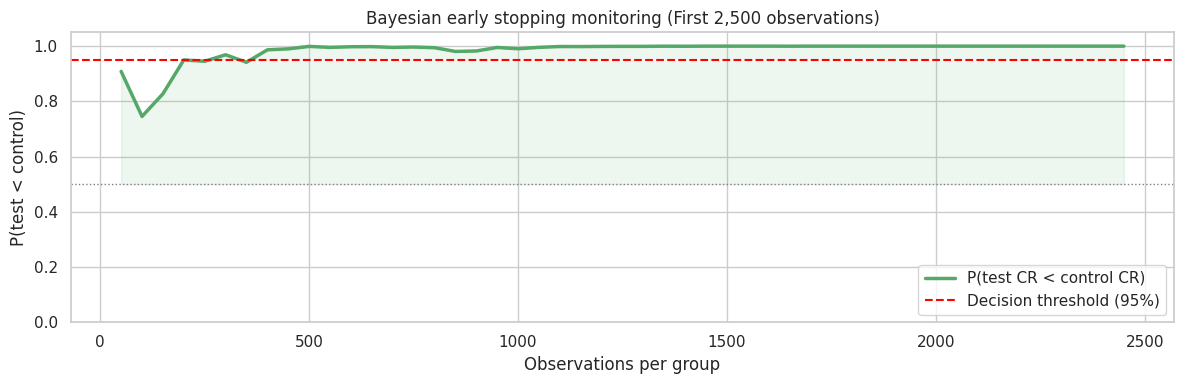

In [28]:
# Фокусируемся строго на старте теста (первые 2500 наблюдений) с шагом в 50 заказов
steps = np.arange(50, min(2500, len(ctrl_sim)), 50)
p_over_time = np.zeros(len(steps))
N_MONITOR_SAMPLES = 5000

for i, n in enumerate(steps):
    bc = ctrl_sim['is_canceled'].iloc[:n].values
    bt = test_sim['is_canceled'].iloc[:n].values

    a_c, b_c = alpha_prior + bc.sum(), beta_prior + n - bc.sum()
    a_t, b_t = alpha_prior + bt.sum(), beta_prior + n - bt.sum()

    sc = beta.rvs(a_c, b_c, size=N_MONITOR_SAMPLES)
    st = beta.rvs(a_t, b_t, size=N_MONITOR_SAMPLES)

    p_over_time[i] = (st < sc).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(steps, p_over_time, color='#55A868', lw=2.5, label='P(test CR < control CR)')
ax.axhline(0.95, ls='--', color='red', label='Decision threshold (95%)')
ax.axhline(0.50, ls=':',  color='grey', lw=1)

ax.fill_between(steps, p_over_time, 0.5, where=(p_over_time > 0.5), alpha=0.1, color='#55A868')

ax.set_title('Bayesian early stopping monitoring (First 2,500 observations)')
ax.set_xlabel('Observations per group')
ax.set_ylabel('P(test < control)')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('img/bayesian_monitoring_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

Байесовская модель пробила порог уверенности в 95% уже на ~400 наблюдениях (11-12 день теста). Несмотря это, эксперимент рекомендуется продлить до минимально необходимого бизнес-цикла, чтобы полностью исключить влияние эффекта новизны и недельной сезонности.

<a id='11'></a>
---
## 11. Guardrail-метрики

**Мотивация:** Фича «Гибкие даты» может непреднамеренно увести пользователей на более дешевые дни или сократить длительность их поездок. Чтобы убедиться, что снижение отмен не наносит вреда экономике бронирований, мы контролируем метрики ADR и Total Nights.

В отличие от целевой метрики, guardrail-показатели (ADR, Total Nights) мы оцениваем строго по чистым, неотмененным бронированиям (`is_canceled == 0`). Это делает метрики независимыми от эффекта снижения отмен. Критерий проверки - двусторонний t-тест ($\alpha = 0.05$).

In [29]:
# Фильтруем только реализованные поездки
ctrl_successful = ctrl_sim[ctrl_sim['is_canceled'] == 0]
test_successful = test_sim[test_sim['is_canceled'] == 0]

guardrails = {
    'adr': 'ADR',
    'total_nights': 'Total Nights'
}

print('Проверка Guardrail-метрик (по успешным бронированиям):')
print('-' * 85)
print(f'{"Метрика":<25} {"Control mean":>12} {"Test mean":>12} {"p-value":>10} {"Статус"}')
print('-' * 85)

all_metrics_safe = True

for col, desc in guardrails.items():
    c_vals = ctrl_successful[col].values
    t_vals = test_successful[col].values

    # Двусторонний тест для фиксации любых изменений
    _, p_val = ttest_ind(c_vals, t_vals, alternative='two-sided')

    # Направление изменения: если тест меньше контроля - это ухудшение
    is_worse = t_vals.mean() < c_vals.mean()

    if p_val <= 0.05 and is_worse:
        status = 'CRITICAL: Значимое ухудшение!'
        all_metrics_safe = False
    elif p_val <= 0.05 and not is_worse:
        status = 'OK (Значимый рост метрики)'
    else:
        status = 'OK (Изменений нет)'

    print(f'{desc:<25} {c_vals.mean():>12.2f} {t_vals.mean():>12.2f} {p_val:>10.4f}  {status}')

print('-' * 85)
print(f'Итог по Guardrail: {"ВСЕ МЕТРИКИ В НОРМЕ" if all_metrics_safe else "ОБНАРУЖЕНО УХУДШЕНИЕ МЕТРИК"}')

Проверка Guardrail-метрик (по успешным бронированиям):
-------------------------------------------------------------------------------------
Метрика                   Control mean    Test mean    p-value Статус
-------------------------------------------------------------------------------------
ADR                             115.17       115.15     0.9558  OK (Изменений нет)
Total Nights                      3.34         3.39     0.0347  OK (Значимый рост метрики)
-------------------------------------------------------------------------------------
Итог по Guardrail: ВСЕ МЕТРИКИ В НОРМЕ


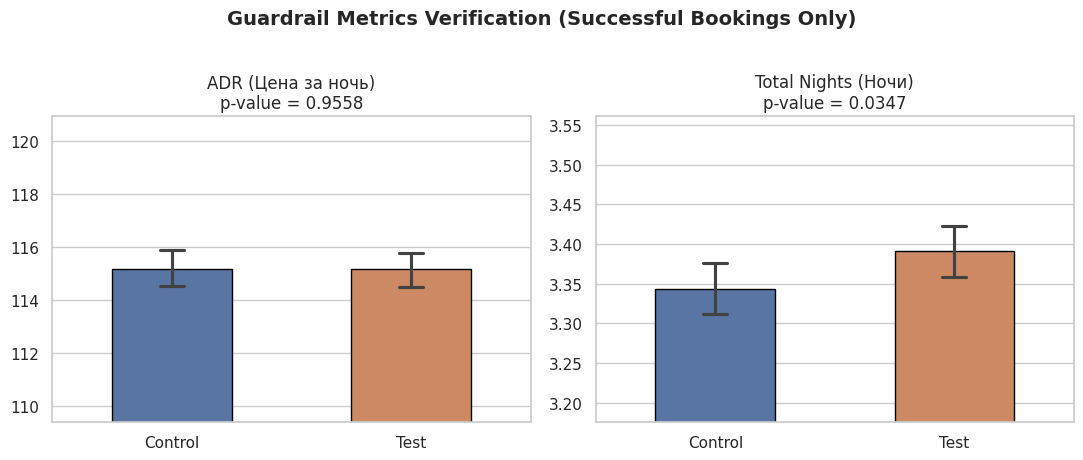

In [30]:
# Берем только успешные поездки
ctrl_successful = ctrl_sim[ctrl_sim['is_canceled'] == 0]
test_successful = test_sim[test_sim['is_canceled'] == 0]

guardrails_plot = {
    'adr': 'ADR (Цена за ночь)',
    'total_nights': 'Total Nights (Ночи)'
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for i, (col, title) in enumerate(guardrails_plot.items()):
    c_vals = ctrl_successful[col].values
    t_vals = test_successful[col].values

    _, p_g = ttest_ind(c_vals, t_vals, alternative='two-sided')

    sns.barplot(
        data=pd.concat([
            pd.DataFrame({'Group': 'Control', col: c_vals}),
            pd.DataFrame({'Group': 'Test', col: t_vals})
        ]),
        x='Group', y=col, ax=axes[i],
        palette=[COLOR_CONTROL, COLOR_TEST],
        errorbar=('ci', 95), capsize=0.1, width=0.5, edgecolor='black'
    )

    axes[i].set_title(f'{title}\np-value = {p_g:.4f}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

    ymin = min(c_vals.mean(), t_vals.mean()) * 0.95
    ymax = max(c_vals.mean(), t_vals.mean()) * 1.05
    axes[i].set_ylim(ymin, ymax)

plt.suptitle('Guardrail Metrics Verification (Successful Bookings Only)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('img/guardrail_metrics_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

### **Наблюдения**:

ADR (Цена за ночь): Изменений нет (p=0.96). Доверительные интервалы практически полностью перекрывают друг друга. Опасения, что фича начнет уводить людей на слишком дешевые даты и снизит средний чек отеля, не подтвердились.

Total Nights (Количество ночей): Зафиксирован статистически значимый рост длительности проживания с 3.34 до 3.39 ночей (p=0.035). Усы интервалов визуально разошлись. Благодаря «Гибким датам» пользователям стало удобнее планировать поездки, и они начали бронировать отели на больший срок. (Понятно, что данные синтетические, и в реальности далеко не факт, что так же получилось бы, но в данном случае эта метрика улучшилась.)

<a id='12'></a>
---
### 12.1. Оценка бизнес-эффекта и расчет ROI

Чтобы перевести статистические результаты в финансовые показатели, мы рассчитаем потенциальный прирост выручки на основе подтвержденного байесовским анализом снижения уровня отмен ($\Delta = 2.83$ п.п.).

**Методологические допущения:**
* **Объем сегмента:** Исторические данные `online_ta` охватывают период в 24 месяца (2 года). На основе этого рассчитывается среднее количество бронирований в месяц.
* **Затраты на разработку (Dev Cost):** Принимаются равными €10 000.
* **Экономика бронирования:** Выручка рассчитывается строго по фактически завершенным (неотмененным) поездкам.

**Риски и продуктовые ограничения:**
1. **Эффект новизны (Novelty Effect):** На старте раскатки метрики могут быть искусственно завышены из-за пользовательского любопытства к новому интерфейсу. Для фиксации чистого долгосрочного эффекта первые 7-14 дней после полноценного релиза рекомендуется исключить из оценки стабильного ROI.
2. **Каннибализация трафика:** Существует гипотеза, что часть пользователей могла перейти в сегмент `Online TA` из других каналов (например, `Direct`), привлеченная новой фичей. Перед масштабированием решения на другие сегменты важно убедиться, что общий Cancel Rate платформы падает пропорционально.

In [31]:
# Исходные параметры
delta_cancel_rate = 0.0283            # Эффект из байесовского теста
avg_gmv_completed = df[df['is_canceled'] == 0]['total_revenue'].mean() # Средний чек бронирования (GMV)
monthly_online_ta = len(online_ta) / 24 # Поток бронирований в месяц
dev_cost_eur = 10_000                 # Стоимость разработки

# КОМИССИЯ АГРЕГАТОРА
take_rate = 0.10

# Расчет аплифта по обороту отелей (GMV)
additional_bookings_monthly = monthly_online_ta * delta_cancel_rate
monthly_gmv_uplift = additional_bookings_monthly * avg_gmv_completed
annual_gmv_uplift  = monthly_gmv_uplift * 12

# Расчет чистой выручки агрегатора
monthly_revenue_uplift = monthly_gmv_uplift * take_rate
annual_revenue_uplift  = annual_gmv_uplift * take_rate

# Расчет окупаемости и ROI для агрегатора
payback_period_months = dev_cost_eur / monthly_revenue_uplift
roi = (annual_revenue_uplift - dev_cost_eur) / dev_cost_eur

print("AGREGATOR FINANCIAL ROI ANALYSIS (Take Rate: 10%)")
print("=" * 65)
print(f"  Подтвержденный эффект (снижение отмен)  : {delta_cancel_rate:.2%}")
print(f"  Средний чек бронирования (GMV)          : {avg_gmv_completed:.2f} EUR")
print(f"  Поток бронирований в месяц (Online TA) : {monthly_online_ta:.0f}")
print(f"  Дополнительные чистые поездки в месяц  : {additional_bookings_monthly:.0f}")
print("-" * 65)
print(f"  [B2B Эффект] Годовой аплифт GMV отелей  : {annual_gmv_uplift:,.0f} EUR")
print("-" * 65)
print(f"  Ежемесячная чистая выручка агрегатора   : {monthly_revenue_uplift:,.0f} EUR")
print(f"  Ожидаемая годовая выручка агрегатора    : {annual_revenue_uplift:,.0f} EUR")
print(f"  Затраты на разработку (Dev Cost)       : {dev_cost_eur:,.0f} EUR")
print("-" * 65)
print(f"  Срок окупаемости фичи (Payback)        : {payback_period_months:.1f} мес.")
print(f"  Годовой ROI проекта для агрегатора      : {roi:.0%}")
print("=" * 65)

AGREGATOR FINANCIAL ROI ANALYSIS (Take Rate: 10%)
  Подтвержденный эффект (снижение отмен)  : 2.83%
  Средний чек бронирования (GMV)          : 354.08 EUR
  Поток бронирований в месяц (Online TA) : 2338
  Дополнительные чистые поездки в месяц  : 66
-----------------------------------------------------------------
  [B2B Эффект] Годовой аплифт GMV отелей  : 281,125 EUR
-----------------------------------------------------------------
  Ежемесячная чистая выручка агрегатора   : 2,343 EUR
  Ожидаемая годовая выручка агрегатора    : 28,113 EUR
  Затраты на разработку (Dev Cost)       : 10,000 EUR
-----------------------------------------------------------------
  Срок окупаемости фичи (Payback)        : 4.3 мес.
  Годовой ROI проекта для агрегатора      : 181%


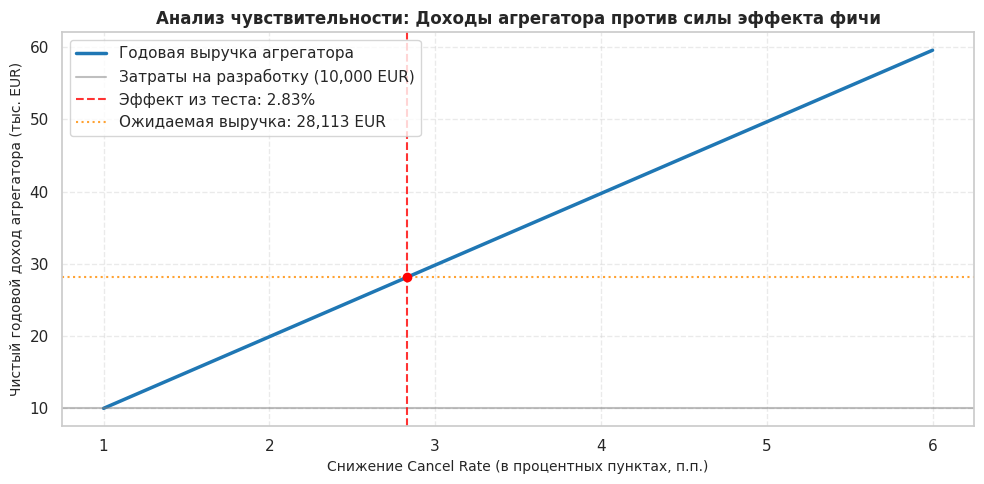

In [32]:
# Sensitivity-анализ: прирост выручки как функция фактического delta
delta_range = np.linspace(0.01, 0.06, 100)
revenue_range_keur = (delta_range * monthly_online_ta * avg_gmv_completed * 12 * take_rate) / 1000

annual_revenue_keur = annual_revenue_uplift / 1000
dev_cost_keur = dev_cost_eur / 1000

fig, ax = plt.subplots(figsize=(10, 5))

# Линия зависимости выручки агрегатора от эффекта
ax.plot(delta_range * 100, revenue_range_keur, color='#1f77b4', lw=2.5, label='Годовая выручка агрегатора')

# Линия затрат на разработку (порог окупаемости)
ax.axhline(dev_cost_keur, ls='-', color='gray', alpha=0.5, label=f'Затраты на разработку ({dev_cost_eur:,.0f} EUR)')

ax.axvline(delta_cancel_rate * 100, ls='--', color='red', alpha=0.8,
           label=f'Эффект из теста: {delta_cancel_rate:.2%}')
ax.axhline(annual_revenue_keur, ls=':', color='darkorange', alpha=0.8,
           label=f'Ожидаемая выручка: {annual_revenue_uplift:,.0f} EUR')

ax.scatter(delta_cancel_rate * 100, annual_revenue_keur, color='red', zorder=5)

ax.set_xlabel('Снижение Cancel Rate (в процентных пунктах, п.п.)', fontsize=10)
ax.set_ylabel('Чистый годовой доход агрегатора (тыс. EUR)', fontsize=10)
ax.set_title('Анализ чувствительности: Доходы агрегатора против силы эффекта фичи', fontsize=12, fontweight='bold')
ax.grid(True, ls='--', alpha=0.4)
ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig('img/roi_sensitivity_aggregator.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Финальное заключение по эксперименту

### **Продуктовый паспорт фичи «Гибкие даты»**

### 1. Концепт и боли пользователей

В классической схеме бронирования изменение планов клиента (отмена рейса, сдвиг отпуска, форс-мажор на работе) приводит к одному сценарию: пользователь вынужден полностью отменить текущее бронирование. Для отеля это означает потерю выручки и пустой номер, а для клиента - стресс и необходимость искать жилье заново.

Фича «Гибкие даты» трансформирует этот процесс. Вместо жесткой отмены платформа предлагает пользователю альтернативу - «бесшовный перенос» бронирования на другие даты в случае непредвиденных обстоятельств.

### 2. Как это устроено для пользователя

* **На этапе бронирования:** Клиент видит плашку «Доступно изменение дат без потери брони». Это повышает уверенность и снижает барьер перед покупкой.
* **В случае форс-мажора:** В личном кабинете рядом с кнопкой «Отменить» появляется кнопка «Изменить даты».
* **Интеллектуальный подбор:** Алгоритм предлагает пользователю пул доступных альтернативных дат (например, со сдвигом на неделю/месяц вперед), где стоимость проживания максимально близка к его исходному чеку.

### 3. Экономическая логика (Почему падают отмены?)

Для системы аналитики отеля это выглядит как снижение Cancel Rate. Фича удерживает клиента внутри экосистемы: старое бронирование трансформируется в реализованную поездку, просто в другой временной отрезок.

### 4. Влияние на метрики (Результаты A/B теста)

Внедрение фичи затронуло ключевые метрики продукта следующим образом:

| Метрика | Результат теста | Аналитическое обоснование |
| --- | --- | --- |
| **Cancel Rate** *(Целевая)* | **Снижение на 2.83 п.п.** | Главный успех фичи. Переносы дат успешно спасли часть бронирований от полной отмены и удержали клиентов на платформе. |
| **ADR** *(Средний чек за ночь)* | **Стабилен** *(Изменений нет, $p = 0.96$)* | Доверительные интервалы групп полностью перекрывают друг друга. Алгоритм подбора работал корректно: он не уводил пользователей на слишком дешевые даты, сохраняя исходный уровень цен отеля (~115 EUR). |
| **Total Nights** *(Длительность)* | **Рост с 3.34 до 3.39 ночей** *($p = 0.035$)* | Статистически значимый позитивный эффект. Усы интервалов на графике визуально разошлись. Получив гибкость в управлении датами, пользователи охотнее бронировали чуть более длинные периоды проживания. *(С поправкой на то, что данные симуляции синтетические, в реальном продукте столь чистый прирост длительности маловероятен, но динамика строго положительная).* |

### 5. Финансовый итог для агрегатора (ROI)

При стоимости разработки в €10 000 и стандартной комиссии агрегатора в 10%, экономика фичи выглядит следующим образом:

* **B2B-эффект:** Дополнительный годовой оборот отелей-партнеров (GMV) составил €281 125. Это сильный аргумент для удержания отелей на платформе.
* **Чистый доход платформы:** Ежемесячный прирост чистой выручки агрегатора составляет €2 343 что транслируется в **€28 113** ожидаемого годового дохода.
* **Окупаемость и ROI:** Проект полностью выходит на точку безубыточности (Payback period) через 4.3 месяца и демонстрирует высокий годовой ROI на уровне 181%.
* **Устойчивость бизнес-модели:** Анализ чувствительности (Sensitivity Analysis) подтверждает, что даже при падении эффективности фичи до минимального уровня в 1.0% (в 2.8 раза хуже результатов теста), проект остаётся рентабельным даже при существенно более слабом эффекте.

---

### **Бизнес-рекомендация и дальнейшие шаги**

1. **Полноценный релиз:** Фича «Гибкие даты» рекомендуется к полноценной раскатке на 100% трафика в канале `Online TA`. Она решает ключевые боли пользователей, защищает партнеров от потери денег и генерирует стабильный доход для агрегатора, не каннибализируя средний чек.
2. **Исключение эффекта новизны:** Чтобы зафиксировать чистый долгосрочный эффект и исключить временный всплеск вовлеченности (Novelty Effect) из-за любопытства пользователей к новому интерфейсу, рекомендуется провести контрольный срез финансовых метрик через 7–14 дней после релиза.